In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

print("Libraries imported successfully!")

Libraries imported successfully!


In [20]:
# STEP 2: Download NLTK Data
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/eswarreddytadi/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/eswarreddytadi/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [21]:
# STEP 3: Set Random Seed

np.random.seed(0)

In [22]:
# STEP 4: Load Data + Preprocessing

df = pd.read_excel("factoryReports.xlsx")
print(df.head())


                                         Description            Category  \
0  Items are occasionally getting stuck in the sc...  Mechanical Failure   
1  Loud rattling and banging sounds are coming fr...  Mechanical Failure   
2  There are cuts to the power when starting the ...  Electronic Failure   
3                 Fried capacitors in the assembler.  Electronic Failure   
4                           Mixer tripped the fuses.  Electronic Failure   

  Urgency          Resolution   Cost  
0  Medium    Readjust Machine     45  
1  Medium    Readjust Machine     35  
2    High    Full Replacement  16200  
3    High  Replace Components    352  
4     Low   Add to Watch List     55  


In [41]:
# Preprocessing:
def preprocess_text(text):
    stop_words = set(stopwords.words('english'))
    words = word_tokenize(str(text).lower())
    filtered_words = [word for word in words if word.isalnum() and word not in stop_words] 
    return ' '.join(filtered_words)


df['Processed_Description'] = df['Description'].apply(preprocess_text)
df['Category'] = df['Category'].astype(str).str.lower()

print("Data loaded and preprocessed successfully!")

Data loaded and preprocessed successfully!


In [24]:
# STEP 6: TF-IDF + Split

vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df['Processed_Description'])

# Target variable
y = df['Category']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (384, 413)
Testing set: (96, 413)


In [40]:
# STEP 7: Train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

In [31]:
# STEP 8: Fit + Predict

# Train (fit) the model and make predictions on the test set
rf_model.fit(X_train, y_train) 
y_pred = rf_model.predict(X_test)

print("Sample Predictions:", y_pred[:10])

Sample Predictions: ['electronic failure' 'electronic failure' 'mechanical failure' 'leak'
 'mechanical failure' 'electronic failure' 'electronic failure'
 'mechanical failure' 'electronic failure' 'mechanical failure']


In [43]:
# STEP 9: Evaluation

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.9062


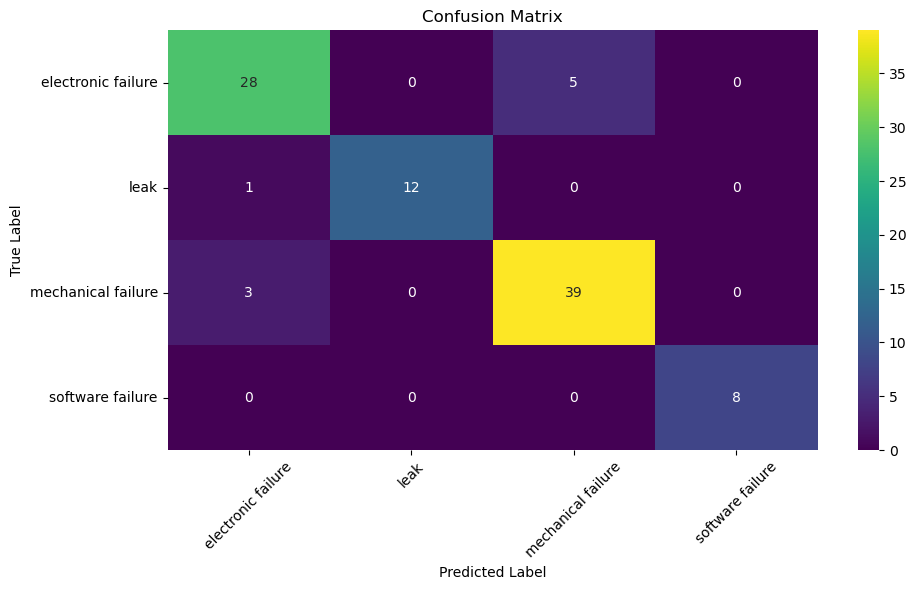

In [39]:
# Define labels
labels = ['electronic failure', 'leak', 'mechanical failure', 'software failure']


conf_matrix = confusion_matrix(y_test, y_pred, labels=labels)
plt.figure(figsize=(10, 6))

sns.heatmap(conf_matrix,
            annot=True,
            fmt='d',
            xticklabels=labels,
            yticklabels=labels,
            cmap='viridis')

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

plt.show()

### Report:

#### Q1:Which techniques would you use for keyword normalization in NLP, the process of converting a keyword into its base form?
Ans:Keyword normalization in NLP can be performed using the following techniques:

Lemmatization: It transforms words into their meaningful base or dictionary form. For eg: “running” becomes “run”.

Stemming: It reduces words to their root form by removing suffixes, even if the resulting word is not always meaningful. For eg: “running” becomes “runn”.

#### Q2:What is TF-IDF in NLP?
Ans:TF-IDF stands for Term Frequency-Inverse Document Frequency: to measure how important a word is within a document relative to a collection of documents (corpus).It helps filter out common words and highlights significant terms.

#### Q3:What are some alternatives for TF-IDF method to parse text data?
Ans:Some widely used alternatives to TF-IDF for text representation include:
Count Vectorization (Bag of Words): Represents text by counting word occurrences.
Word2Vec: Generates dense vector representations capturing semantic relationships.
FastText: Extends Word2Vec by considering subword information.

#### Q4:What advantage(s) does word2vec has over TF-IDF?
Ans:Word2Vec has several advantages over TF-IDF:

It captures semantic relationships between words, meaning similar words have similar vector representations.
It produces dense, low-dimensional vectors, whereas TF-IDF generates sparse and high-dimensional representations.
It considers the context in which words appear, helping the model understand meaning more effectively.

#### Q5:Provide two applications of the above lab assignment problem?
Ans: 

Automated Maintenance Ticketing Systems.

Categorizing customer service complaints into predefined topics.